<a href="https://colab.research.google.com/github/JohnUfo/python-and-scikit-tutorial/blob/main/scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [233]:
url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'
from urllib.request import urlretrieve
urlretrieve(url, 'medical.csv')

import pandas as pd
medical_df = pd.read_csv('medical.csv')

In [234]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [235]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('input.shape : ', inputs.shape)
print('targets.shape : ', targets.shape)

input.shape :  (1064, 1)
targets.shape :  (1064,)


In [236]:
model.fit(inputs, targets)

LinearRegression()

In [237]:
print("weight : ", model.coef_)
print("bias : ", model.intercept_)

weight :  [267.24891283]
bias :  -2091.4205565650864


When we call `model.fit()` for **Linear Regression**,  
the model learns `w` and `b` by minimizing **Ordinary Least Squares (OLS)**.

In [238]:
model.predict(pd.DataFrame({'age': [23, 37, 61]}))

array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [239]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [240]:
from sklearn.metrics import root_mean_squared_error

In [241]:
root_mean_squared_error(targets, predictions)

4662.505766636395

In [242]:
def try_parameters(w,b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges
  estimated_charges = ages*w+b

  plt.plot(ages,estimated_charges,'r')
  plt.scatter(ages,target,s=5)
  plt.xlabel('Age')
  plt.ylabel('Charges')
  plt.legend(['Estimated Charges','Actual Charges'])

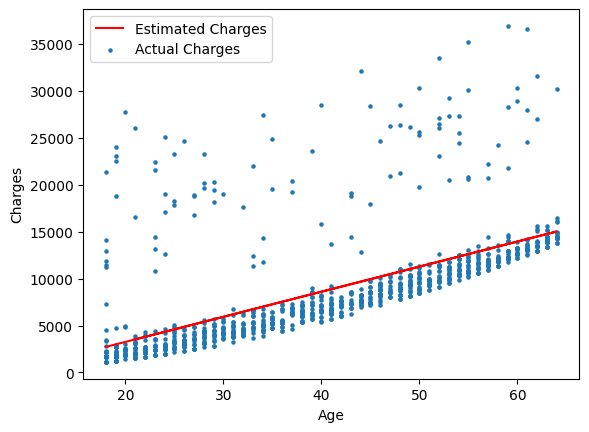

In [243]:
try_parameters(model.coef_, model.intercept_)

# Now I will try it with SGDRegressor

In [244]:
from sklearn.linear_model import SGDRegressor
sgd_model = SGDRegressor(max_iter=10000,eta0=0.0001, tol=None)
sgd_model.fit(inputs, targets)

SGDRegressor(eta0=0.0001, max_iter=10000, tol=None)

In [245]:
sgd_predictions = sgd_model.predict(inputs)
root_mean_squared_error(targets, sgd_predictions)

4662.696835611934

In [246]:
inputs, targets = non_smoker_df[['age']], non_smoker_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
root_mean_squared_error(targets, predictions)

4662.505766636395

# Train With Age And BMI

In [247]:
inputs, targets = non_smoker_df[['age','bmi']],non_smoker_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
root_mean_squared_error(targets, predictions)

4662.3128354612945

There is no strong relationship between charges and bmi. There is no nearly any improvement in the loss

In [248]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

In [249]:
fig = px.scatter(non_smoker_df, x='bmi', y='charges', title='BMI vs Charges')
fig.update_traces(marker_size=5)
fig.show()

There is no any relationship with charges and bmi. there is no any line

In [250]:
print('weight for age: ', model.coef_[0])
print('weight for bmi: ', model.coef_[1])
print('bias: ', model.intercept_)

weight for age:  266.876578165998
weight for bmi:  7.075476658142241
bias:  -2293.6320906488727


In [251]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [252]:
fig = px.strip(non_smoker_df, x='children', y='charges', title='Children vs Charges')
fig.update_traces(marker_size=5)
fig.show()

In [253]:
inputs, targets = non_smoker_df[['age','bmi','children']],non_smoker_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
root_mean_squared_error(targets, predictions)

4608.470405038247

In [254]:
print('weight for age: ', model.coef_[0])
print('weight for bmi: ', model.coef_[1])
print('weight for children: ', model.coef_[2])
print('bias: ', model.intercept_)

weight for age:  265.29384429763684
weight for bmi:  5.279563132041638
weight for children:  580.6596505255704
bias:  -2809.2976032235892


In [255]:
smokers = medical_df[medical_df.smoker == 'yes']

In [256]:
inputs, targets = smokers[['age','bmi','children']], smokers.charges
model = LinearRegression().fit(inputs,targets)
predictions = model.predict(inputs)
root_mean_squared_error(targets, predictions)

5718.202480524154

In [257]:
inputs, targets = medical_df[['age','bmi','children']], medical_df.charges
model = LinearRegression().fit(inputs,targets)
predictions = model.predict(inputs)
root_mean_squared_error(targets, predictions)

11355.317901125973

In [258]:
print('weight for age: ', model.coef_[0])
print('weight for bmi: ', model.coef_[1])
print('weight for children: ', model.coef_[2])
print('bias: ', model.intercept_)

weight for age:  239.9944742936462
weight for bmi:  332.0833645034481
weight for children:  542.8646522470186
bias:  -6916.243347787033


# CATEGORICAL FEATURES

In [259]:
smoker_codes = {'no':0,"yes":1}
medical_df.smoker = medical_df.smoker.map(smoker_codes)

In [260]:
medical_df.charges.corr(medical_df.smoker)

np.float64(0.787251430498478)

In [261]:
inputs, targets = medical_df[['age','bmi','smoker']], medical_df.charges
model = LinearRegression().fit(inputs,targets)
predictions = model.predict(inputs)
root_mean_squared_error(targets,predictions)

6083.206042088949

In [262]:
sex_code = {'female':0,'male':1}
medical_df.sex = medical_df.sex.map(sex_code)

In [263]:
inputs, targets = medical_df[['age','bmi','smoker','sex']], medical_df.charges
model = LinearRegression().fit(inputs,targets)
predictions = model.predict(inputs)
root_mean_squared_error(targets,predictions)

6082.963823733165

In [264]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])

OneHotEncoder()

In [265]:
one_hot = enc.transform(medical_df[['region']]).toarray()

In [266]:
medical_df[['northeast','northwest','southeast','southwest']] = one_hot

In [268]:
input_cols = ['age','bmi','smoker','sex','northeast','northwest','southeast','southwest']
targets = medical_df.charges

In [271]:
model = LinearRegression().fit(medical_df[input_cols], targets)
predictions = model.predict(medical_df[input_cols])
root_mean_squared_error(targets, predictions)

6068.68259297263